## 1 Coloration des sommets d’un graphes avec sagemath

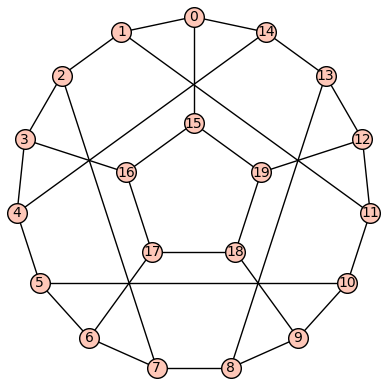

In [1]:
g = graphs.FlowerSnark()
g.show()

In [2]:
g.order(), g.size()

(20, 30)

##### L’argument partition de la méthode show() reçoit, comme son nom l’indique, une partition de l’ensemble des
##### sommets. Une couleur est alors attribuée à chaque ensemble de la partition, afin de les séparer visuellement. Une
##### dernière couleur est attribuée aux sommets n’apparaissant pas dans la partition. Dans notre exemple on a donc en
##### tout trois couleurs.

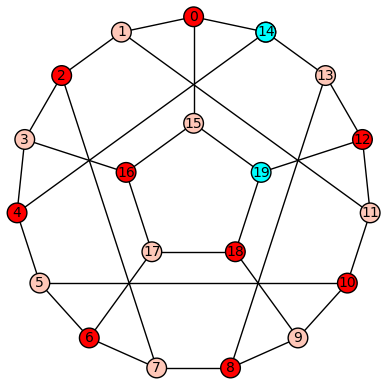

In [3]:
S = [[0, 2, 4, 6, 8, 10, 12, 14, 16, 18], [14, 19]]
g.show(partition = S)

##### Dans la suite, un graphe sera toujours défini par sa matrice d’adjacence.
##### Vous pourrez tester vos fonctions avec le graphe suivant :

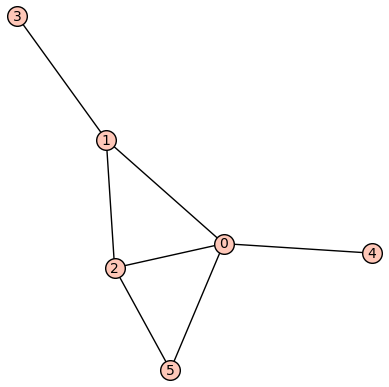

In [3]:
M = matrix([[0,1,1,0,1,1],[1,0,1,1,0,0],[1,1,0,0,0,1],[0,1,0,0,0,0],[1,0,0,0,0,0],[1,0,1,0,0,0]])
g = Graph(M)
g.show()

## Exercice 1.
##### Construire une fonction color1(M, sommets) qui retourne une partition permettant :
##### — d’affecter des couleurs distinctes aux sommets donnés en paramètres.
##### — de colorer les autres sommets d’une autre couleur.
##### Exemple d’utilisation : 
##### C = color1(M, [0, 2, 4])
##### g.show(partition = C)

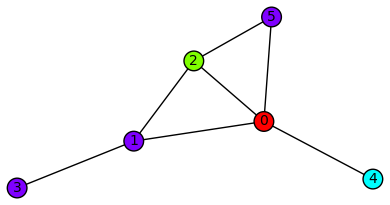

In [4]:
def color1(M, sommets):
    n = M.nrows()
    partition = [[s] for s in sommets]
    
    autres = [i for i in range(n) if i not in sommets]
    partition.append(autres)
    
    return partition

C = color1(M, [0, 2, 4])
g.show(partition = C)

## Exercice 2.
#### Construire une fonction color2(M, x) qui retourne une partition permettant :
#### — de colorer le sommet x, ainsi que ses voisins, avec une couleur différente pour chacun d’entre eux ;
#### — de colorer les autres sommets d’une autre couleur.
### Remarque.
#### Penser à utiliser la fonction voisins() du TP précédent.
#### Exemple d’utilisation.
#### P = color2(M, 2)
#### g.show(partition = P)

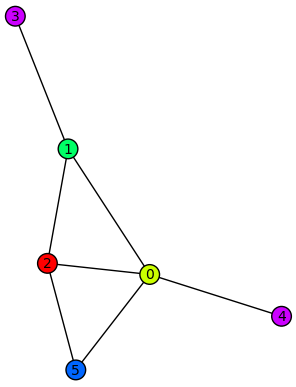

In [7]:
def voisins(M, x):
    n = M.nrows()
    vois = []
    for j in range(n):
        if M[x,j] == 1:
            vois.append(j)
    return vois

def color2(M, x):
    n = M.nrows()
    vois = voisins(M, x)
    
    partition = [[x]] + [[v] for v in vois]
    
    autres = [i for i in range(n) if i != x and i not in vois]
    partition.append(autres)
    
    return partition

P = color2(M, 2)
g.show(partition = P)

## Exercice 3.
#### Construire une fonction color3(M) qui retourne une liste d’entiers permettant :
#### — de colorer en une couleur le(s) sommet(s) de plus haut degré, et en une autre couleur celui(/ceux) de plus bas degré ;
#### — de colorer les autres sommets d’une autre couleur.
### Remarque.
#### Penser à utiliser la fonction degre() du TP précédent.
#### Exemple d’utilisation.
#### C = color3(M)
#### g.show(partition = C)

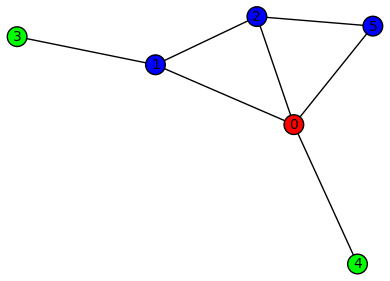

In [8]:
def degre(M, x):
    n = M.nrows()
    deg = 0
    for j in range(n):
        if M[x,j] == 1:
            deg += 1
    return deg

def color3(M):
    n = M.nrows()
    
    degres = [degre(M, i) for i in range(n)]
    
    max_deg = max(degres)
    sommets_max = [i for i in range(n) if degres[i] == max_deg]
    
    min_deg = min(degres)
    sommets_min = [i for i in range(n) if degres[i] == min_deg]
    
    partition = [sommets_max, sommets_min]
    
    autres = [i for i in range(n) if i not in sommets_max and i not in sommets_min]
    partition.append(autres)
    
    return partition

C = color3(M)
g.show(partition = C)

# 2 Algorithmes de coloration de graphe
## 2.1 Algorithme glouton (simplifié)
### Concaténer deux listes
#### Voici trois solutions possibles pour concaténer ou fusionner deux listes.
#### 1. l’addition

In [9]:
x = [10, 20,30,40]
y = [12, 14, 16, 18]
z = [55, 44, 66, 99]
opération = x + y + z
print ("Liste concaténée:\n", str (opération))

Liste concaténée:
 [10, 20, 30, 40, 12, 14, 16, 18, 55, 44, 66, 99]


#### 2. la méthode append()

In [10]:
liste1 = ['A','B','C']
liste2 = ['D','E','F']
for element in liste2 :
    liste1.append(element)
print("Liste concaténée:\n",liste1)

Liste concaténée:
 ['A', 'B', 'C', 'D', 'E', 'F']


#### 3. la méthode extend()

In [11]:
liste1 = ['A','B','C']
liste2 = ['D','E','F']
liste1.extend(liste2)
print("Liste concaténée:\n",liste1)

Liste concaténée:
 ['A', 'B', 'C', 'D', 'E', 'F']


## Exercice 4.
### 1.

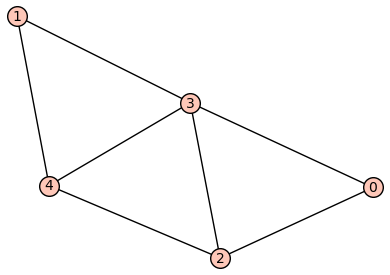

In [12]:
M1 = matrix ([[0,0,1,1,0],
             [0,0,0,1,1],
             [1,0,0,1,1],
             [1,1,1,0,1],
             [0,1,1,1,0]])


G = Graph(M1)    # Graphe non-orienté de matrice d'adjacence M1
G.show()        # Afficher le diagramme du graphe

#### 2. Créer une fonction glouton(M) qui retourne une partition des sommets de g permettant de colorer un graphe
#### de matrice M grâce à l’algorithme glouton simplifié.

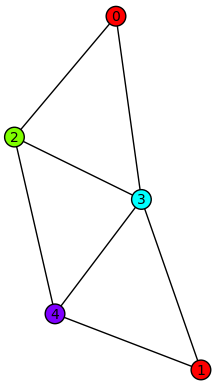

In [13]:
def glouton(M):
    n = M.nrows()
    # liste de couleurs pour chaque sommet
    couleurs = []
    for i in range(n):
        couleurs.append(None)

    for x in range(n):
        # les couleurs des voisins de x
        couleurs_voisins = []
        for j in range(n):
            if M[x,j] == 1:            
                if couleurs[j] is not None:
                    # ajout de la couleur si elle n'est pas déjà dans la liste
                    if couleurs[j] not in couleurs_voisins:
                        couleurs_voisins.append(couleurs[j])
        # trouver la plus petite couleur non utilisée
        c = 0
        while c in couleurs_voisins:
            c = c + 1
        couleurs[x] = c

    # transformer la liste de couleurs en partition
    partition = []
    for couleur in range(max(couleurs) + 1):
        group = []
        for sommet in range(n):
            if couleurs[sommet] == couleur:
                group.append(sommet)
        partition.append(group)
    return partition

P2 = glouton(M1)
G.show(partition=P2)

## Exercice 5.
#### Construire une fonction tri_degre(M,Bool) qui renvoie la liste des sommets triés suivant leur degré(dans l’ordre décroissant si Bool = True , croissant sinon).

In [23]:
def tri_degre(M, Bool):
    n = M.nrows()
    # liste des paires (sommet, degré)
    liste = []
    for i in range(n):
        liste.append((i, degre(M, i)))
    # trier selon le degré
    # si Bool True, décroissant (reverse=True)
    liste.sort(key=lambda paire: paire[1], reverse=Bool)
    # ne renvoyer que les sommets
    return [s for s, d in liste]

print(tri_degre(M, False))   # ordre croissant
print(tri_degre(M, True))    # ordre décroissant

[3, 4, 5, 1, 2, 0]
[0, 1, 2, 5, 3, 4]
